In [2]:
# !pip install tensorflow
# !pip install numpy
# !pip install optuna
# !pip install optuna-dashboard
# !pip install jupyterlab jupyterlab-optuna
# !pip install -q optuna

In [12]:
import tensorflow as tf
import keras

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)


TensorFlow version: 2.16.2
Keras version: 3.2.1


In [33]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import os
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping

In [34]:
# define model attributes
image_width = 200
image_height = 141 
seed = 1
batch_size = 32
epochs = 100
# learning_rate = 2.114025303155737e-05
learning_rate = 0.0001
random_rotation = 0.2
dataset_path = "/Users/aguszulvani/privacy/MKOM/1-PROPOSAL-TESIS/CODE/dataset/train"

# Load training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='categorical',
    color_mode='grayscale',
    image_size=(image_height, image_width),
    validation_split=0.2,
    batch_size=batch_size, 
    seed=seed,
    subset="training",
    class_names=[name for name in os.listdir(dataset_path) if name != '.DS_Store']
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='categorical',
    validation_split=0.2,
    subset="validation",
    color_mode='grayscale',
    seed=seed,
    image_size=(image_height, image_width),
    batch_size=batch_size,
    class_names=[name for name in os.listdir(dataset_path) if name != '.DS_Store']
)

# Get class names before further processing
class_names = train_ds.class_names
print("Class names:", class_names)

# Optional: Prefetch to optimize performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Found 5400 files belonging to 27 classes.
Using 4320 files for training.
Found 5400 files belonging to 27 classes.
Using 1080 files for validation.
Class names: ['input-free-text', 'radio-button', 'hyperlink', 'input-number', 'time-picker', 'image-card', 'alert', 'pie-chart', 'checkbox', 'label', 'slider', 'bar-chart', 'common-image-button', 'image', 'combobox', 'key-value', 'textarea', 'date-picker', 'table', 'list', 'segmented-button', 'common-button', 'input-password', 'switch', 'line-chart', 'icon-button', 'input-file']
Image batch shape: (32, 141, 200, 1)
Label batch shape: (32, 27)


2026-05-04 22:41:24.100965: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


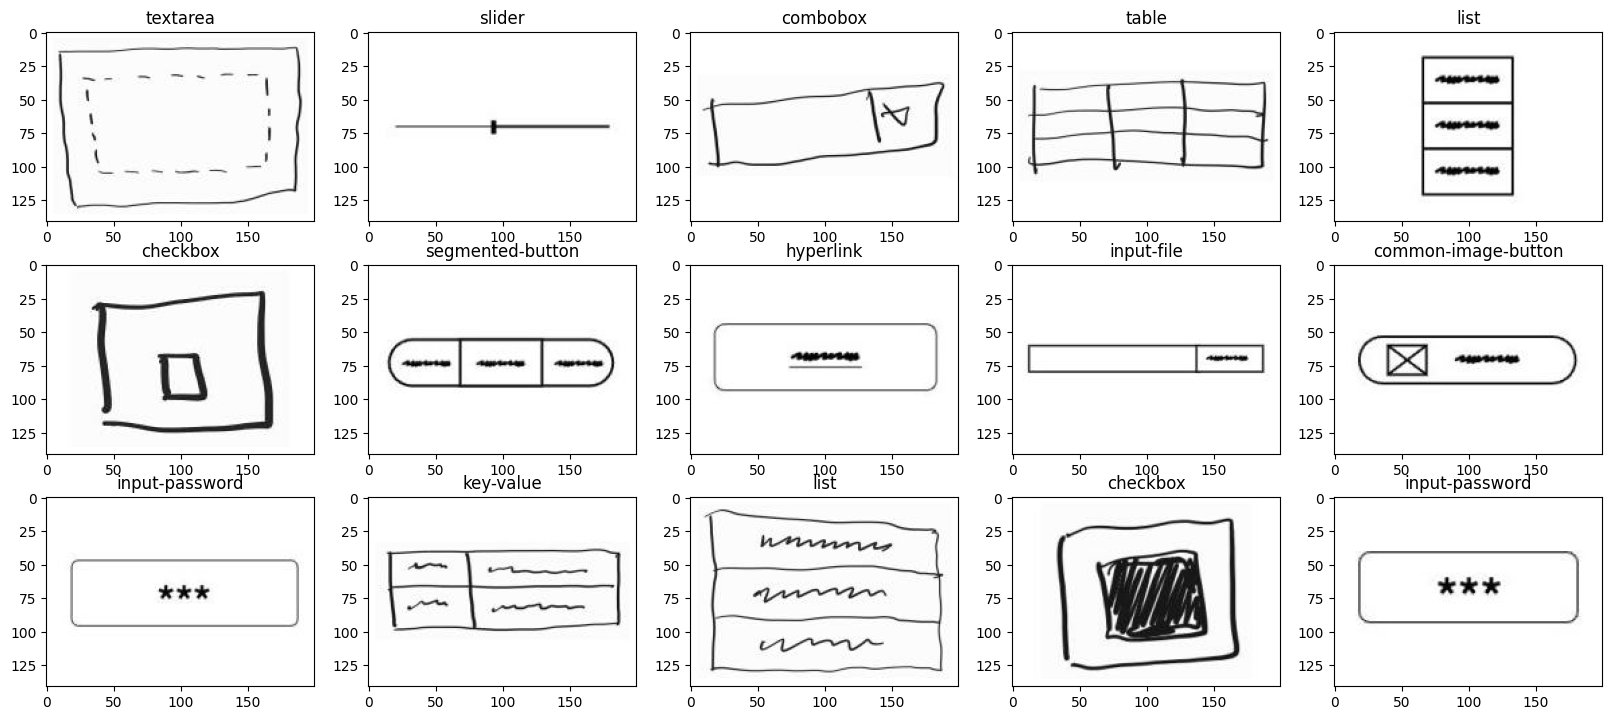

2026-05-04 22:41:37.321629: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [35]:
for image_batch, label_batch in train_ds.take(1):
    plt.figure(figsize=(20.08, 14.6))
    for i in range(15):
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(image_batch[i].numpy().astype("float32"), cmap='gray')
        plt.title(class_names[tf.argmax(label_batch[i])])
        # plt.title(f"{class_names[tf.argmax(label_batch[i])]} ({image_file})")
        # plt.title(f"{image_batch}")
        plt.axis("on")
    plt.show()


# for image_batch, label_batch in val_ds.take(1):
#     plt.figure(figsize=(20, 14))
#     for i in range(10):
#         ax = plt.subplot(5, 5, i + 1)
#         plt.imshow(image_batch[i].numpy().astype("float32"), cmap='gray')
#         plt.title(class_names[tf.argmax(label_batch[i])])
#         plt.axis("off")
#     plt.show()

In [ ]:
# !pip install optuna_integration

In [ ]:
# Sketch Deep Net CNN model with early stopping
early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

# Define a Sketch Deep Net CNN model
model = models.Sequential([
    # layers.RandomRotation(random_rotation),
    layers.Conv2D(64, (5, 5), activation='relu', input_shape=(image_height, image_width, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(512, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    # layers.GlobalAveragePooling2D(),

    # fully connected layers
    layers.Dense(1024, activation='relu'),
    layers.Dense(1024, activation='relu'),
    # layers.Dropout(0.25173261671801894),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')  # Output layer
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics = [tf.keras.metrics.Precision(),]
    # metrics=['accuracy']
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping]
)



In [ ]:
from tensorflow.keras.layers import Concatenate
from tensorflow.keras import Model, Input

# OUR PROPOSE Model with GAP + GMP and early stopping
early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

# Need functional API for this
inputs = Input(shape=(image_height, image_width, 1))
x = layers.Conv2D(64,  (5, 5), activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, (3, 3), activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(256, (3, 3), activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(512, (3, 3), activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

# Combine GAP + GMP → (None, 1024)
gap = layers.GlobalAveragePooling2D()(x)
gmp = layers.GlobalMaxPooling2D()(x)
x = layers.Concatenate()([gap, gmp])

x = layers.Dense(1024, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics = [tf.keras.metrics.Precision(),]
    # metrics=['accuracy']
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping]
)

Epoch 1/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 19s 116ms/step - loss: 2.4011 - precision: 0.7313 - val_loss: 7.4312 - val_precision: 0.0306
Epoch 2/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 18s 131ms/step - loss: 0.5442 - precision: 0.9412 - val_loss: 7.6846 - val_precision: 0.0432
Epoch 3/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 18s 135ms/step - loss: 0.2342 - precision: 0.9788 - val_loss: 7.2893 - val_precision: 0.0529
Epoch 4/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 19s 138ms/step - loss: 0.1192 - precision: 0.9841 - val_loss: 3.1437 - val_precision: 0.3198
Epoch 5/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 19s 141ms/step - loss: 0.0743 - precision: 0.9903 - val_loss: 0.4598 - val_precision: 0.9132
Epoch 6/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 64s 478ms/step - loss: 0.0416 - precision: 0.9970 - val_loss: 0.1150 - val_precision: 0.9839
Epoch 7/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 18s 137ms/step - loss: 0.0314 - precision: 0.9982 - val_loss: 0.0911 - val_precision: 0.9878
Epoch 8/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 33s 241ms/step - loss

In [37]:
print(history.history.keys())


dict_keys(['loss', 'precision', 'val_loss', 'val_precision'])


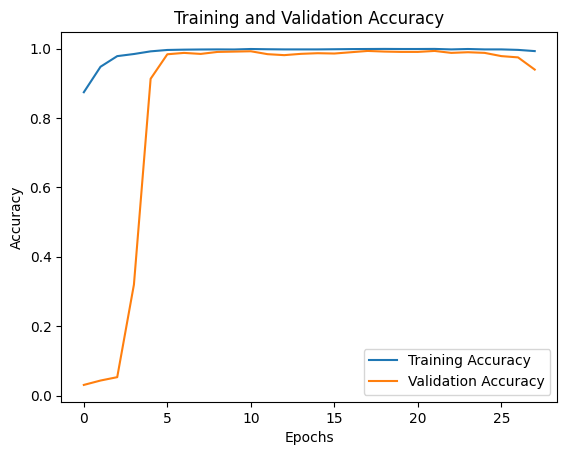

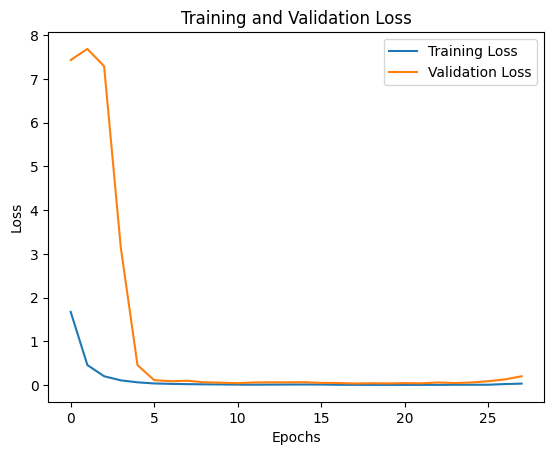

In [39]:
# plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['precision'], label='Training Accuracy')
plt.plot(history.history['val_precision'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# import optuna
# from optuna.integration import TFKerasPruningCallback

# def create_model(trial):
#     # Define hyperparameters to tune
#     # num_conv_layers = trial.suggest_int('num_conv_layers', 1, 4)
#     # num_filters = trial.suggest_categorical('num_filters', [32, 64, 128, 256])
#     # kernel_size = trial.suggest_categorical('kernel_size', [3, 5])
#     dense_units = trial.suggest_int('dense_units', 128, 1024)
#     dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
#     learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)

#     # model = models.Sequential()
#     # model.add(layers.RandomRotation(0.2))
#     # model.add(layers.Conv2D(num_filters, (kernel_size, kernel_size), activation='relu', input_shape=(image_height, image_width, 1)))
#     # model.add(layers.MaxPooling2D((2, 2)))

#     # for _ in range(num_conv_layers - 1):
#     #     model.add(layers.Conv2D(num_filters, (kernel_size, kernel_size), activation='relu'))
#     #     model.add(layers.MaxPooling2D((2, 2)))

#     # model.add(layers.Flatten())
#     # model.add(layers.Dense(dense_units, activation='relu'))
#     # model.add(layers.Dropout(dropout_rate))
#     # model.add(layers.Dense(len(class_names), activation='softmax'))

#     model = models.Sequential([
#         layers.RandomRotation(0.2),
#         layers.Conv2D(64, (5, 5), activation='relu', input_shape=(image_height, image_width, 1)),
#         layers.MaxPooling2D((2, 2)),

#         layers.Conv2D(128, (3, 3), activation='relu'),
#         layers.MaxPooling2D((2, 2)),

#         layers.Conv2D(256, (3, 3), activation='relu'),
#         layers.MaxPooling2D((2, 2)),

#         layers.Conv2D(512, (3, 3), activation='relu'),
#         layers.MaxPooling2D((2, 2)),

#         layers.Flatten(),
#         # layers.Dense(1024, activation='relu'),
#         layers.Dense(dense_units, activation='relu'),
#         layers.Dropout(dropout_rate),
#         layers.Dense(len(class_names), activation='softmax')  # Output layer
#     ])

#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
#         loss='categorical_crossentropy',
#         metrics=['accuracy']
#     )

#     return model

# def objective(trial):
#     model = create_model(trial)

#     history = model.fit(
#         train_ds,
#         validation_data=val_ds,
#         epochs=epochs,
#         callbacks=[TFKerasPruningCallback(trial, 'val_loss'), early_stopping],
#         verbose=0
#     )

#     val_accuracy = history.history['val_accuracy'][-1]
#     return val_accuracy

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

# print("Best trial:")
# trial = study.best_trial
# print(f"  Value: {trial.value}")
# print("  Params: ")
# for key, value in trial.params.items():
#     print(f"    {key}: {value}")

In [ ]:
# import numpy as np

# # #  Convert dataset to numpy arrays
# def dataset_to_numpy(dataset):
#     images = []
#     labels = []
#     for image_batch, label_batch in dataset:
#         images.append(image_batch.numpy())
#         labels.append(label_batch.numpy())
#     return np.concatenate(images), np.concatenate(labels)

# k = 5 
# images, labels = dataset_to_numpy(train_ds)

# # # Initialize KFold
# kf = KFold(n_splits=k, shuffle=True, random_state=42)

# # Loop through each fold
# fold_num = 1
# for train_index, val_index in kf.split(images):
#     print(f"Training fold {fold_num}/{k}...")
    
#     # Split data into training and validation sets
#     train_images, val_images = images[train_index], images[val_index]
#     train_labels, val_labels = labels[train_index], labels[val_index]
    
#     # Ensure the data is in the correct format
#     train_images = np.array(train_images)
#     train_labels = np.array(train_labels)
#     val_images = np.array(val_images)
#     val_labels = np.array(val_labels)
    
#     # Train the model
#     history = model.fit(
#         train_images, train_labels,
#         validation_data=(val_images, val_labels),
#         epochs=epochs,
#         batch_size=batch_size
#     )

#     # Evaluate on the validation set
#     val_loss, val_accuracy = model.evaluate(val_images, val_labels)
#     print(f"Fold {fold_num} - Validation Loss: {val_loss}, Validation Accuracy: {val_accuracy}")

#     train_loss, train_accuracy = model.evaluate(train_images, train_labels)
#     print(f"Fold {fold_num} - Validation Loss: {train_loss}, Validation Accuracy: {train_accuracy}")

#     fold_num += 1